In [ ]:
x=1

In [1]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import jax, jax.numpy as jnp
from flax.training import orbax_utils
import orbax.checkpoint
from types import SimpleNamespace
import numpy as np  # ### <<< Import numpy for final stats

from pobax.config import PPOHyperparams
from pobax.envs import get_env
from pobax.models import ScannedRNN, ActorCritic
from pobax.algos.ppo import PPO, env_step, calculate_gae

from pobax.models import get_network_fn
from pobax.utils.file_system import get_results_path, numpyify
import functools
import optax
from pathlib import Path
from flax.training.train_state import TrainState

# ---------- 1.  Load checkpoint ----------
ckpt_path = "/home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/rocksample_7_8_seed(2024)_time(20250731-154403)_2b4fcdbf78add77a258884e5436772ae"

ckptr      = orbax.checkpoint.PyTreeCheckpointer()
ckpt       = ckptr.restore(ckpt_path)
args_dict  = ckpt["args"]
args = PPOHyperparams().from_dict(args_dict)

print(f"Loaded checkpoint from {ckpt_path}")

# ---------- 2.  Recreate shared env/network components ----------
# We only need one instance of the env and network definition
env_key = jax.random.PRNGKey(2)
args.num_envs = int(1e6) # Number of parallel episodes per evaluation run

env, env_params = get_env(args.env, env_key,
                          num_envs=args.num_envs,
                          gamma=args.gamma,
                          action_concat=args.action_concat)

network_fn, action_size, is_image, is_discrete = get_network_fn(env, env_params)
network = network_fn(args.env, action_size,
                     double_critic=args.double_critic,
                     hidden_size=args.hidden_size,
                     memoryless=args.memoryless,
                     is_discrete=is_discrete,
                     is_image=is_image)

agent = PPO(network,
            double_critic=args.double_critic,
            ld_weight=args.ld_weight[0], # Use the first value, as it's the same for all
            alpha=args.alpha[0],
            vf_coeff=args.vf_coeff[0],
            entropy_coeff=args.entropy_coeff,
            clip_eps=args.clip_eps)

_env_step = functools.partial(env_step, agent=agent, env=env, env_params=env_params)


# ### <<< STEP 1: Get ALL sets of parameters from the checkpoint
# The shape is (1, 1, 1, 1, 1, 1, 3, 512). We want the 3 sets from the 7th dimension (index 6).
unpacked_params = ckpt["final_train_state"]["params"]
# We use tree_map to apply this slicing to every parameter tensor in the PyTree.
params_all_seeds = jax.tree.map(lambda x: x.squeeze(axis=(0,1,2,3,4,5)), unpacked_params)

# ### <<< Get the number of seeds dynamically
num_seeds = params_all_seeds["params"]["actor"]["Dense_0"]["bias"].shape[0]
print(f"Found parameters for {num_seeds} seeds.")


# ---------- 3.  Define and JIT the parallel evaluation ----------

# ### <<< STEP 2: Modify the function to accept parameters for a single run
def one_eval(params_for_one_run, rng):
    # Create a temporary TrainState for this inference run. The optimizer state (`tx`) is not used.
    inference_state = TrainState.create(apply_fn=network.apply, params=params_for_one_run, tx=optax.adam(1e-3))
    
    reset_key, scan_key = jax.random.split(rng)
    obs, env_state = env.reset(jax.random.split(reset_key, args.num_envs), env_params)
    hstate = ScannedRNN.initialize_carry(args.num_envs, args.hidden_size)
    runner_state = (inference_state, env_state, obs, jnp.zeros(args.num_envs, bool), hstate, scan_key)

    runner_state, traj = jax.lax.scan(_env_step, runner_state, None, env_params.max_steps_in_episode)

    info = traj.info
    mask = info["returned_episode"]
    # jnp.where is a safe way to mask inside a JIT-ted function
    masked_returns = jnp.where(mask, info["returned_discounted_episode_returns"], 0.0)
    num_episodes = jnp.sum(mask)
    # Ensure we don't divide by zero if no episodes finish
    mean_return = jnp.sum(masked_returns) / jnp.maximum(num_episodes, 1)
    
    return mean_return

# ### <<< STEP 3: Vectorize the evaluation function
# Map `one_eval` over the parameters (axis 0) and new random keys (axis 0)
vmapped_eval = jax.vmap(one_eval, in_axes=(0, 0))
jitted_vmapped_eval = jax.jit(vmapped_eval)


# ---------- 4.  Execute evaluation and print results ----------
# ### <<< Create a unique random key for each parallel evaluation
eval_rng_key = jax.random.PRNGKey(42)
eval_rng_keys = jax.random.split(eval_rng_key, num_seeds)

# ### <<< Run the vectorized evaluation
# This will run `one_eval` 3 times in parallel, once for each seed's parameters
print("Running parallel evaluation across all seeds...")
all_mean_returns = jitted_vmapped_eval(params_all_seeds, eval_rng_keys)

# ### <<< Compute and print final statistics
final_avg_return = np.mean(all_mean_returns)
final_std_return = np.std(all_mean_returns)

print("\n--- Evaluation Complete ---")
print(f"Individual mean returns per seed: {np.array(all_mean_returns)}")
print(f"Final Average Return across {num_seeds} seeds: {final_avg_return:.4f}")
print(f"Final Standard Deviation across {num_seeds} seeds: {final_std_return:.4f}")

ModuleNotFoundError: No module named 'jax'

In [43]:
import jax, jax.numpy as jnp
from flax.training import orbax_utils
import orbax.checkpoint
from types import SimpleNamespace

from pobax.config import PPOHyperparams
from pobax.envs import get_env
from pobax.models import ScannedRNN, ActorCritic
from pobax.algos.ppo import PPO, env_step, calculate_gae   # import symbols you already defined

from pobax.models import ScannedRNN, get_network_fn
from pobax.utils.file_system import get_results_path, numpyify
import functools
import optax 
from pathlib import Path
from flax.training.train_state import TrainState
from pobax.models import get_gymnax_network_fn
from gymnax.environments import environment, spaces
# ---------- 1.  Load checkpoint ----------

# chkpath for roomba
#ckpt_path = "/home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/roomba_seed(2024)_time(20250731-020404)_43c7c57e55488e7016a575342b19d04c"           # directory created earlier

#ckpt_path = "/home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/lightdark_seed(2025)_time(20250730-134529)_5824f9e29097cf1b61429303e9df7058"

ckpt_path = "/home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/rocksample_7_8_seed(2024)_time(20250731-154403)_2b4fcdbf78add77a258884e5436772ae"

ckptr      = orbax.checkpoint.PyTreeCheckpointer()
ckpt       = ckptr.restore(ckpt_path)         # returns the dict you saved
train_state_data = ckpt["final_train_state"]

#print(f"type(train_state_data): {type(train_state_data)}")
# Re‑wrap params so PPO’s code can access `.params`
args_dict   = ckpt["args"]                    # hyper-parameters

def get_gymnax_network_fn(env: environment.Environment, env_params: environment.EnvParams,
                          memoryless: bool = False):
    
    
    # check type of action space
    if isinstance(env.action_space(env_params), spaces.Discrete):
        print("Action space is discrete")
        action_size = env.action_space(env_params).n
    else:
        action_size = env.action_space(env_params).shape[0]
    print(f"type of action space: {type(env.action_space(env_params))}")
    print(f"env.action_space(env_params): {env.action_space(env_params).shape}")
    print(f"env.observation_space(env_params): {env.observation_space(env_params)}")
    
   
    
    network_fn = ActorCritic
    
        
    return network_fn, action_size

unpacked_ts = ckpt["final_train_state"]["params"]#ckpt['out']['runner_state'][0]

key = jax.random.PRNGKey(0)
env, env_params = get_env(args_dict['env'], key,
                        args_dict['gamma'],
                        action_concat=args_dict['action_concat'])

network_fn, action_size = get_gymnax_network_fn(env, env_params, memoryless=args_dict['memoryless'])

network = network_fn(action_size,
                    double_critic=args_dict['double_critic'],
                    hidden_size=args_dict['hidden_size'],
                    memoryless= args_dict['memoryless'],
                    is_discrete=False,
                    action_dim=action_size,
                    is_image=False)


tx = optax.adam(args_dict['lr'][0])
train_state = TrainState.create(apply_fn=network.apply,
                    params=jax.tree.map(lambda x: x[0, 0, 0, 0, 0,0,0], unpacked_ts),
                    tx=tx)





args = PPOHyperparams().from_dict(args_dict)

args.num_envs = int(1e6)
args.lamda = 0.95
print(f"Loaded checkpoint from {ckpt_path}")
print(f"Hyperparameters: {args}")

# ---------- 2.  Recreate env/network ----------
env_key = jax.random.PRNGKey(0)

env, env_params = get_env(args.env, env_key,
                          num_envs=args.num_envs,
                          image_size=args.image_size,
                          gamma=args.gamma,
                          perfect_memory=args.perfect_memory,
                          action_concat=args.action_concat)

network_fn, action_size, is_image, is_discrete = get_network_fn(env, env_params)
network = network_fn(args.env, action_size,
                     double_critic=args.double_critic,
                     hidden_size=args.hidden_size,
                     memoryless=args.memoryless,
                     is_discrete=is_discrete,
                     is_image=is_image)

agent = PPO(network,
            double_critic=args.double_critic,
            ld_weight=args.ld_weight,
            alpha=args.alpha,
            vf_coeff=args.vf_coeff,
            entropy_coeff=args.entropy_coeff,
            clip_eps=args.clip_eps)

_env_step = functools.partial(env_step, agent=agent, env=env, env_params=env_params)

# ---------- 3.  Evaluate five episodes ----------
def one_eval(rng):
    reset_key, scan_key = jax.random.split(rng)
    obs, env_state = env.reset(jax.random.split(reset_key, args.num_envs), env_params)
    hstate = ScannedRNN.initialize_carry(args.num_envs, args.hidden_size)
    runner_state = (train_state, env_state, obs, jnp.zeros(args.num_envs, bool), hstate, scan_key)
    runner_state, traj = jax.lax.scan(_env_step, runner_state, None, env_params.max_steps_in_episode)
    info = traj.info
    mask = info["returned_episode"]
    # Non-concrete boolean indexing is not allowed inside jax.vmap.
    # Instead, we use jnp.where to select the returns of finished episodes
    # and then calculate the mean.
    masked_returns = jnp.where(mask, info["returned_discounted_episode_returns"], 0.0)
    num_episodes = jnp.sum(mask)
    mean_return = jnp.sum(masked_returns) / jnp.maximum(num_episodes, 1)
    return mean_return, traj








Action space is discrete
type of action space: <class 'gymnax.environments.spaces.Discrete'>
env.action_space(env_params): ()
env.observation_space(env_params): <gymnax.environments.spaces.Dict object at 0x7ebf96a02dd0>
Loaded checkpoint from /home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/rocksample_7_8_seed(2024)_time(20250731-154403)_2b4fcdbf78add77a258884e5436772ae
Hyperparameters: {'action_concat': False,
 'alpha': array([1.], dtype=float32),
 'anneal_lr': False,
 'clip_eps': 0.27925836640722684,
 'debug': True,
 'default_max_steps_in_episode': 100,
 'double_critic': False,
 'entropy_coeff': 0.021022446642184302,
 'env': 'rocksample_7_8',
 'gamma': 0.95,
 'hidden_size': 512,
 'image_size': 32,
 'lambda0': array([0.52431667], dtype=float32),
 'lambda1': array([0.9236773], dtype=float32),
 'lamda': 0.95,
 'ld_weight': array([0.], dtype=float32),
 'lr': array([6.469462e-05], dtype=float32),
 'max_grad_norm': 1.9215668540906852,
 'memoryless': False,
 'minibatch_

In [39]:
unpacked_ts["params"]["actor"]["Dense_0"]["bias"].shape

(1, 1, 1, 1, 1, 1, 3, 512)

In [31]:
args_dict

{'action_concat': False,
 'alpha': array([1.], dtype=float32),
 'anneal_lr': False,
 'clip_eps': 0.27925836640722684,
 'debug': True,
 'default_max_steps_in_episode': 100,
 'double_critic': False,
 'entropy_coeff': 0.021022446642184302,
 'env': 'rocksample_7_8',
 'gamma': 0.95,
 'hidden_size': 512,
 'image_size': 32,
 'lambda0': array([0.52431667], dtype=float32),
 'lambda1': array([0.9236773], dtype=float32),
 'ld_weight': array([0.], dtype=float32),
 'lr': array([6.469462e-05], dtype=float32),
 'max_grad_norm': 1.9215668540906852,
 'memoryless': False,
 'minibatch_size': 4096,
 'n_seeds': 3,
 'num_envs': 64,
 'num_epochs': 50,
 'num_eval_envs': 5,
 'num_minibatches': 4,
 'num_steps': 256,
 'perfect_memory': False,
 'platform': 'gpu',
 'save_checkpoints': False,
 'save_runner_state': False,
 'seed': 2024,
 'show_discounted': True,
 'steps_log_freq': 1,
 'study_name': 'batch_ppo_test',
 'total_steps': 800000,
 'update_epochs': 7,
 'update_log_freq': 1,
 'vf_coeff': array([0.425991], dt

NUM ENVS: 10000
[Eval 1/5] Avg discounted return: 7.74
[Eval 2/5] Avg discounted return: 7.74
[Eval 3/5] Avg discounted return: 7.74
[Eval 4/5] Avg discounted return: 7.74
[Eval 5/5] Avg discounted return: 7.74
average across 5 episodes: 7.74
 std across 5 episodes: 0.00
Actions shape: (5, 1000, 10000)
Rewards shape: (5, 1000, 10000)
Done flags shape: (5, 1000, 10000)
Returned Discounted Episode Returns shape: (5, 1000, 10000)
Returned Episode Lengths shape: (5, 1000, 10000)

--- Trajectory 1 ---


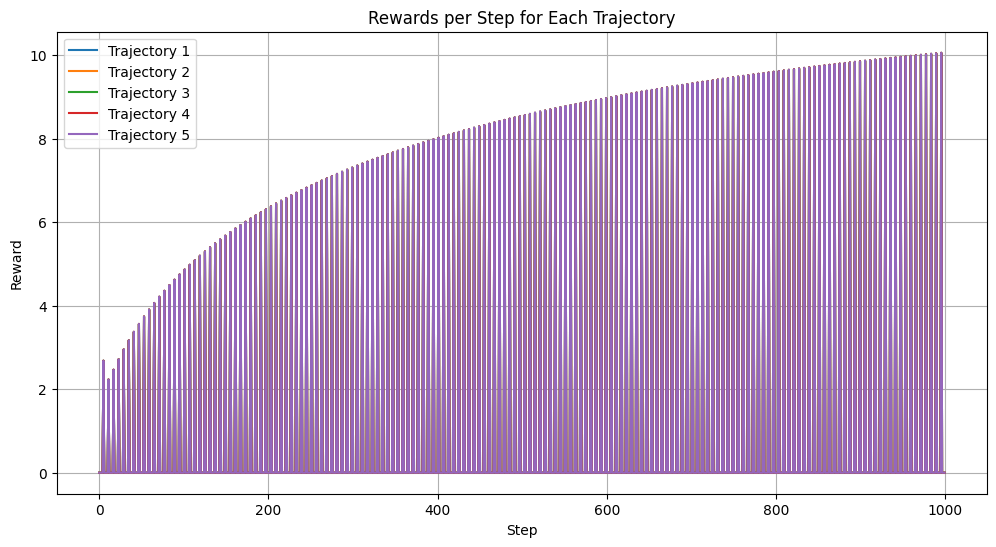

==

--- Step 1 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 2 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 3 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 4 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 5 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 6 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 7 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 8 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 9 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 10 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 11 ---
Action: 1
Reward: 0.0
Done: False
------------------------------
==

--- Step 12 ---
Action: 1
Reward: 0.0
Done: False
--------------------

In [24]:

rngs = jax.random.split(jax.random.PRNGKey(42), 5)
episode_returns, trajectories = jax.vmap(one_eval)(rngs)






print(f"NUM ENVS: {args.num_envs}")
for i, r in enumerate(episode_returns, 1):
    print(f"[Eval {i}/5] Avg discounted return: {r:.2f}")
    
    
print(f"average across 5 episodes: {jnp.mean(episode_returns):.2f}")
print(f" std across 5 episodes: {jnp.std(episode_returns):.2f}")
6.30




# I want to show information about trajectory, the actions taken the observation, etrc
# Example of how to print trajectory information
actions = trajectories.action
rewards = trajectories.reward
done = trajectories.done

observations = trajectories.obs
info = trajectories.info



returned_discounted_episode_returns = info["returned_discounted_episode_returns"]
returned_episode_lengths = info["returned_episode_lengths"]


# Print the shape of the arrays
print(f"Actions shape: {actions.shape}")
#print(f"Observations shape: {observations.shape}")
print(f"Rewards shape: {rewards.shape}")
print(f"Done flags shape: {done.shape}")
print(f"Returned Discounted Episode Returns shape: {returned_discounted_episode_returns.shape}")
print(f"Returned Episode Lengths shape: {returned_episode_lengths.shape}")



# look at one trajectory
trajectory_index = 0  # Change this to look at different trajectories
simulation_index = 2
print(f"\n--- Trajectory {trajectory_index + 1} ---")









# create a plot to show the reward at each step for all trajectories
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(actions.shape[0]):
    plt.plot(rewards[i, :, 0], label=f'Trajectory {i + 1}')
plt.title('Rewards per Step for Each Trajectory')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.legend()
plt.grid()
plt.show()

for step in range(actions.shape[1]):
    print("==")
    print(f"\n--- Step {step + 1} ---")
    print(f"Action: {actions[trajectory_index][simulation_index][step]}")
    #print(f"Observation: {observations[trajectory_index][simulation_index][step]}")
    print(f"Reward: {rewards[trajectory_index][simulation_index][step]}")
    print(f"Done: {done[trajectory_index][simulation_index][step]}")
    print("-" * 30)
    if done[trajectory_index][simulation_index][step]:
        print("Episode finished.")
        break








In [5]:
rewards.shape

(5, 1000, 10000)

In [6]:
rewards[0]

Array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [7]:
actions.shape

(5, 1000, 10000)

In [8]:
actions.shape

(5, 1000, 10000)

In [9]:
import numpy as np
np.mean(actions)

Array(1.0000441, dtype=float32)

In [10]:
np.min(actions), np.max(actions)

(Array(0, dtype=int32), Array(12, dtype=int32))

In [11]:
np.min(rewards), np.max(rewards)

(Array(-100.00491, dtype=float32), Array(100.00491, dtype=float32))

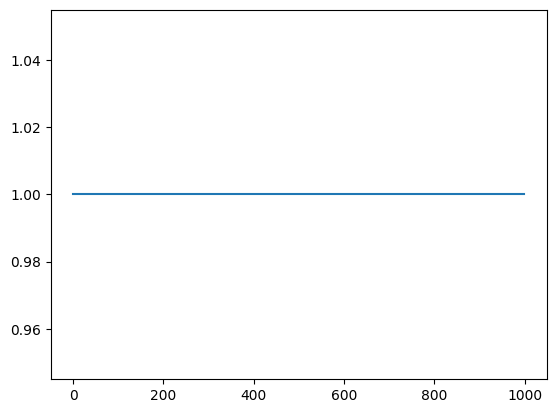

In [12]:
plt.plot(actions[0, :, 1], label='Action 0')

In [26]:
rewards[0].shape

(1000, 10000)

In [28]:
unique_r, r_counts = np.unique(rewards, return_counts=True)
for r, count in zip(unique_r, r_counts):
    print(f"rewards {r}: chosen {count} times")

rewards -100.00491333007812: chosen 2 times
rewards -10.055495262145996: chosen 1 times
rewards -10.04289436340332: chosen 1 times
rewards -10.03701400756836: chosen 1 times
rewards -10.031919479370117: chosen 1 times
rewards -10.020221710205078: chosen 1 times
rewards -10.012612342834473: chosen 1 times
rewards -9.994427680969238: chosen 1 times
rewards -9.98409652709961: chosen 1 times
rewards -9.98218822479248: chosen 1 times
rewards -9.969841957092285: chosen 1 times
rewards -9.958210945129395: chosen 1 times
rewards -9.945874214172363: chosen 1 times
rewards -9.944555282592773: chosen 1 times
rewards -9.937129974365234: chosen 1 times
rewards -9.932048797607422: chosen 1 times
rewards -9.920204162597656: chosen 1 times
rewards -9.919316291809082: chosen 1 times
rewards -9.911397933959961: chosen 1 times
rewards -9.884993553161621: chosen 1 times
rewards -9.879712104797363: chosen 1 times
rewards -9.871746063232422: chosen 1 times
rewards -9.866451263427734: chosen 1 times
rewards 

In [13]:
returned_discounted_episode_returns.shape

(5, 1000, 10000)

In [14]:
returned_episode_lengths.shape

(5, 1000, 10000)

In [15]:
np.mean(returned_discounted_episode_returns), np.std(returned_discounted_episode_returns)

(Array(7.699055, dtype=float32), Array(0.55085254, dtype=float32))

In [16]:
# find epsiodes where agent gets high reward
indexes = np.where(returned_discounted_episode_returns > 9)
print(f"Indexes of high reward episodes: {indexes}")

Indexes of high reward episodes: (array([0, 0, 0, ..., 4, 4, 4], shape=(1378,)), array([ 30,  31,  32, ..., 975, 976, 977], shape=(1378,)), array([ 634,  634,  634, ..., 5799, 5799, 5799], shape=(1378,)))


In [17]:
actions[indexes]

Array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [18]:
actions.max()

Array(12, dtype=int32)

In [19]:
unique_actions, action_counts = np.unique(actions, return_counts=True)
for action, count in zip(unique_actions, action_counts):
    print(f"Action {action}: chosen {count} times")

Action 0: chosen 526 times
Action 1: chosen 49998693 times
Action 3: chosen 176 times
Action 4: chosen 464 times
Action 5: chosen 36 times
Action 6: chosen 11 times
Action 7: chosen 15 times
Action 8: chosen 20 times
Action 9: chosen 20 times
Action 10: chosen 11 times
Action 11: chosen 10 times
Action 12: chosen 18 times


In [20]:
returned_discounted_episode_returns[0]

Array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [7.7378087, 7.7378087, 7.7378087, ..., 7.7378087, 7.7378087,
        7.7378087],
       [7.7378087, 7.7378087, 7.7378087, ..., 7.7378087, 7.7378087,
        7.7378087],
       [7.7378087, 7.7378087, 7.7378087, ..., 7.7378087, 7.7378087,
        7.7378087]], dtype=float32, weak_type=True)

In [21]:
np.mean(returned_episode_lengths), np.std(returned_episode_lengths)

(Array(5.970155, dtype=float32), Array(0.42340466, dtype=float32))